In [6]:

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from shapesimilarity import shape_similarity
from scipy.spatial import procrustes
from scipy.spatial.distance import cdist

In [7]:
#load lamina - labeled from Kawtars image
data=pd.read_csv("lamina2 (1).csv",header=None)
data

,0,1
0,115.680147,359.159314
1,158.647059,358.057598
2,192.800245,364.667892
3,196.105392,392.210784
4,166.359069,407.634804
...,...,...
127,174.071078,183.986520
128,196.105392,208.224265
129,191.698529,232.462010
130,169.664216,241.275735


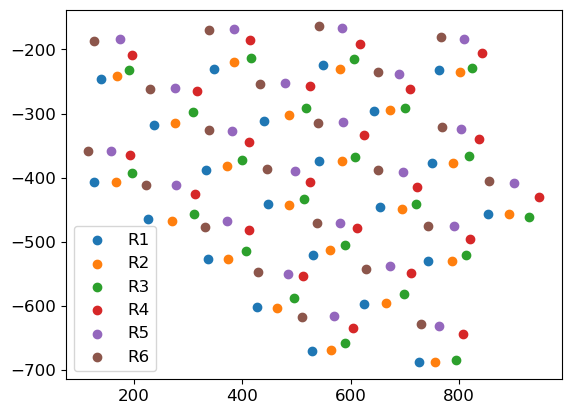

In [8]:
# label /bundles/prs (mirrowed from picture)
x=data[0]
y=data[1]
data[2]= np.repeat(np.arange(1, 23), 6)
data[3] = np.tile(np.arange(6, 0, -1), 22)
data[4]=data[2].astype(str)
groups = np.asarray(data[3])   

for g in np.unique(groups):
    mask = groups == g
    plt.scatter( x[mask], -y[mask], label=f"R{g}")

plt.legend(loc="lower left", fontsize=12)
plt.tick_params(axis="both", labelsize=12)
plt.show()

In [8]:
#get every bundle

shapes=[]

for i in range(1, 23):

    shape1=data[data[2]==i]
    shape1 = shape1.sort_values(by=3)
    shapes.append(shape1)

In [9]:
shapes

[            0           1  2  3  4
 5  126.697304  407.634804  1  1  1
 4  166.359069  407.634804  1  2  1
 3  196.105392  392.210784  1  3  1
 2  192.800245  364.667892  1  4  1
 1  158.647059  358.057598  1  5  1
 0  115.680147  359.159314  1  6  1,
              0           1  2  3  4
 11  226.953431  464.924020  2  1  2
 10  271.022059  467.127451  2  2  2
 9   311.785539  457.212010  2  3  2
 8   312.887255  426.363971  2  4  2
 7   277.632353  412.041667  2  5  2
 6   222.546569  412.041667  2  6  2,
              0           1  2  3  4
 17  236.868873  317.294118  3  1  3
 16  275.428922  315.090686  3  2  3
 15  308.480392  297.463235  3  3  3
 14  316.192402  265.513480  3  4  3
 13  276.530637  260.004902  3  5  3
 12  230.258578  262.208333  3  6  3,
              0           1  2  3  4
 23  332.718137  388.905637  4  1  4
 22  372.379902  382.295343  4  2  4
 21  399.922794  372.379902  4  3  4
 20  412.041667  343.735294  4  4  4
 19  381.193627  327.209559  4  5  4
 18  

# Local mean shape

In [10]:
################################
# mean ref bundle
################################

coords = [s[[0, 1]].to_numpy() for s in shapes]
ref = coords[0]

aligned = []
for shape in coords:
    refa, shapea, disparity = procrustes(ref, shape)
    aligned.append(shapea)


mean_shape1 = np.mean(np.stack(aligned), axis=0)

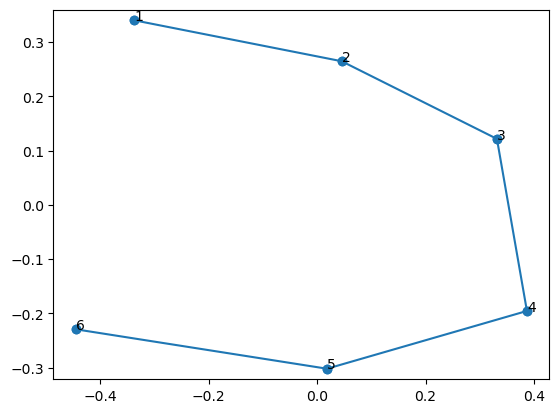

In [11]:


plt.scatter(mean_shape1[:,0], mean_shape1[:,1])
plt.plot(mean_shape1[:,0], mean_shape1[:,1], '-o')

for i, (x, y) in enumerate(mean_shape1, start=1):
    plt.text(x, y, str(i))

plt.axis('equal')
plt.show()

In [14]:
mean_shape1

array([[-0.33763799,  0.34050575],
       [ 0.04531781,  0.2649262 ],
       [ 0.33164232,  0.12171464],
       [ 0.38695094, -0.19559415],
       [ 0.01827538, -0.3020918 ],
       [-0.44454847, -0.22946064]])

# Global grid

In [9]:
data=pd.read_csv("lamina2 (1).csv",header=None)

data["x"] = data[0]
data["y"] = data[1]
x=data[0]
y=data[1]
data["bundle"]=arr = np.repeat(np.arange(1, 23), 6)
data["pr"] = np.tile(np.arange(0, 6), 22)

groups = np.asarray(data["bundle"])

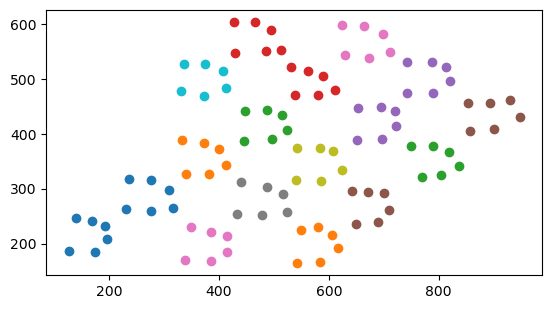

In [10]:
# "wrong" orientation
#not exact top-bottom but i need grid
mask = groups == 3
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=1"
)
mask = groups == 4
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=6"
)
mask = groups == 7
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=7"
)
mask = groups == 10
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=14"
)
mask = groups == 11
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=9"
)
mask = groups == 12
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=5"
)
mask = groups == 14
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=2"
)
mask = groups == 15
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=3"
)
mask = groups == 16
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=8"
)
mask = groups == 17
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=12"
)
mask = groups == 22
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=0"
)

mask = groups == 5
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=4"
)

mask = groups == 9
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=10"
)

mask = groups == 13
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=13"
)

mask = groups == 18
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=16"
)

mask = groups == 19
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=11"
)

mask = groups == 20
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=15"
)

ax = plt.gca()
ax.set_aspect("equal", adjustable="box")

#plt.legend()
plt.show()

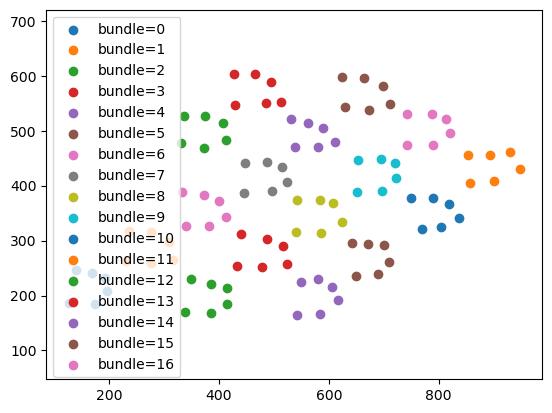

In [11]:
group_to_b = {
    3: 1,
    4: 6,
    5: 4,
    7: 7,
    9: 10,
    10: 14,
    11: 9,
    12: 5,
    13: 13,
    14: 2,
    15: 3,
    16: 8,
    17: 12,
    18: 16,
    19: 11,
    20: 15,
    22: 0,
}

data["matched_bundle"] = data["bundle"].map(group_to_b)
labeled = data.dropna(subset=["matched_bundle"]).copy()
labeled["matched_bundle"] = labeled["matched_bundle"].astype(int)



for b in sorted(labeled["matched_bundle"].unique()):
    g = labeled[labeled["matched_bundle"] == b]

    plt.scatter(
        g["x"],
        g["y"],
        label=f"bundle={b}"
    )

plt.axis("equal")
plt.legend()
plt.show()

In [12]:
bundle_cs=[]
bundle_ids=[]
for b in sorted(labeled["matched_bundle"].unique()):
    g = labeled[labeled["matched_bundle"] == b]
    bundle =  list(zip(g["x"], g["y"]))

    #bundle center for global grid
    if len(bundle) > 0:
        center = np.mean(bundle, axis=0)
        bundle_cs.append(center)
        bundle_ids.append(b)
        
bundle_cs = np.array(bundle_cs)       
bundle_cs

array([[166.17544935, 216.48713235],
       [273.95996732, 286.26245915],
       [381.10181781, 197.84977533],
       [479.61356209, 277.9995915 ],
       [579.68607026, 198.67606209],
       [677.37152778, 269.73672386],
       [372.9307598 , 356.77226307],
       [486.04023693, 416.99938725],
       [580.78778595, 346.30596405],
       [689.85763889, 421.58986928],
       [794.52062908, 350.7128268 ],
       [896.79656863, 436.27941176],
       [372.37990196, 499.26082516],
       [468.96364379, 574.17749183],
       [568.6689134 , 493.38500817],
       [666.90522876, 567.38357843],
       [782.58537582, 504.40216503]])

In [13]:
bundle_centers_df = pd.DataFrame({
    "bundle": bundle_ids,
    "x": bundle_cs[:, 0],
    "y": bundle_cs[:, 1],
})

out_path = f"bundle_centers_bio.csv"
bundle_centers_df.to_csv(out_path, index=False)

print("saved bundle centers to:", out_path)

saved bundle centers to: bundle_centers_bio.csv


# Dif. Orientation (more correct)

In [15]:
data

,0,1,x,y,bundle,pr,yflip
0,115.680147,359.159314,115.680147,359.159314,1,0,-359.159314
1,158.647059,358.057598,158.647059,358.057598,1,1,-358.057598
2,192.800245,364.667892,192.800245,364.667892,1,2,-364.667892
3,196.105392,392.210784,196.105392,392.210784,1,3,-392.210784
4,166.359069,407.634804,166.359069,407.634804,1,4,-407.634804
...,...,...,...,...,...,...,...
127,174.071078,183.986520,174.071078,183.986520,22,1,-183.986520
128,196.105392,208.224265,196.105392,208.224265,22,2,-208.224265
129,191.698529,232.462010,191.698529,232.462010,22,3,-232.462010
130,169.664216,241.275735,169.664216,241.275735,22,4,-241.275735


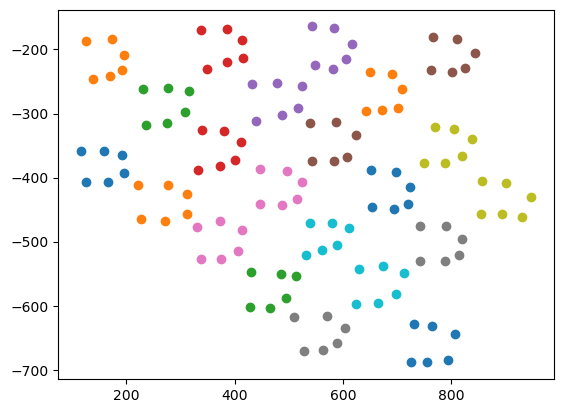

In [17]:
data["yflip"]= - data["y"]


x=data[0]
y=data["yflip"]

groups = np.asarray(data["bundle"])  
for g in np.unique(groups):
    mask = groups == g
    plt.scatter( x[mask], y[mask], label=f"pr={g}")

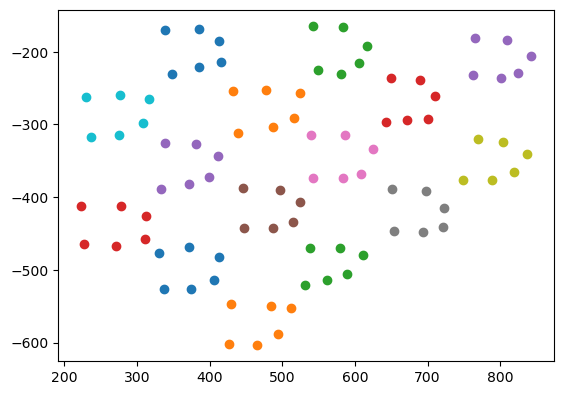

In [46]:
# "correct" orientation
#smaller than incorrect

mask = groups == 17
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=3"
)

mask = groups == 13
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=4"
)
mask = groups == 10
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=5"
)



mask = groups == 2 #
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=6"
)

mask = groups == 4
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=7"
)
mask = groups == 7
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=8"
)
mask = groups == 16
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=9"
)
mask = groups == 11
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=10"
)
mask = groups == 9
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=11"
)



mask = groups == 3
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=12"
)
mask = groups == 14
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=13"
)
mask = groups == 15
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=14"
)
mask = groups == 5
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=15"
)


mask = groups == 12
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=16"
)

mask = groups == 6 #
plt.scatter(
    x[mask],
    y[mask],
    label=f"bundle=17"
)

ax = plt.gca()
ax.set_aspect("equal", adjustable="box")

#plt.legend()
plt.show()

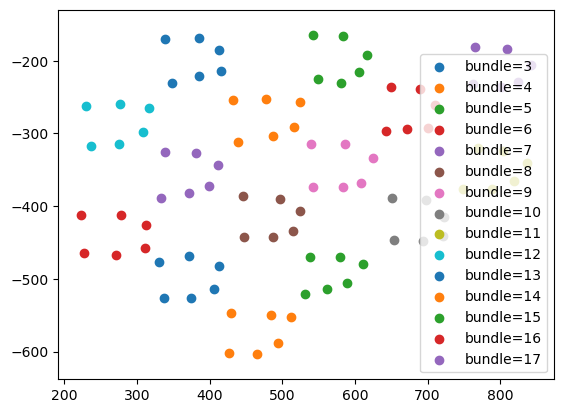

In [48]:
group_to_b = {
    17: 3,
    13: 4,
    10: 5,
    2: 6,
    4: 7,
    7: 8,
    16: 9,
    11: 10,
    9: 11,
    3: 12,
    14: 13,
    15: 14,
    5: 15,
    12: 16,
    6: 17,
}

data["matched_bundle2"] = data["bundle"].map(group_to_b)
labeled = data.dropna(subset=["matched_bundle2"]).copy()
labeled["matched_bundle2"] = labeled["matched_bundle2"].astype(int)



for b in sorted(labeled["matched_bundle2"].unique()):
    g = labeled[labeled["matched_bundle2"] == b]

    plt.scatter(
        g["x"],
        g["yflip"],
        label=f"bundle={b}"
    )

plt.axis("equal")
plt.legend()
plt.show()

In [49]:
bundle_cs = []
bundle_ids = []
for b in sorted(labeled["matched_bundle2"].unique()):
    g = labeled[labeled["matched_bundle2"] == b]
    bundle = list(zip(g["x"], g["yflip"]))

    #bundle center for global grid
    if len(bundle) > 0:
        center = np.mean(bundle, axis=0)
        bundle_cs.append(center)
        bundle_ids.append(b)

bundle_cs = np.array(bundle_cs)
bundle_cs
bundle_centers_df = pd.DataFrame({
    "bundle": bundle_ids,
    "x": bundle_cs[:, 0],
    "y": bundle_cs[:, 1],
})

out_path = f"bundle_centers_bio2.csv"
bundle_centers_df.to_csv(out_path, index=False)

print("saved bundle centers to:", out_path)

saved bundle centers to: bundle_centers_bio2.csv
